 (a) Plot the observations.

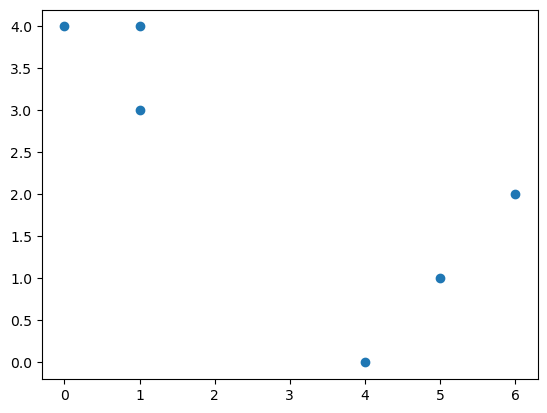

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x1= np.array([1,1,0,5,6,4])
x2= np.array([4,3,4,1,2,0])

plt.scatter(x1, x2)
plt.show()

(b) Randomly assign a cluster label to each observation. You can use
 the np.random.choice() function to do this. Report the cluster
 labels for each observation.

In [2]:
np.random.seed(42)

# Randomly assign cluster labels (assuming 2 clusters, labels 0 or 1)
n_observations = len(x1)
cluster_labels = np.random.choice([0, 1], size=n_observations)

print("Cluster labels for each observation:")
for i in range(n_observations):
    print(f"Observation {i+1}: (x1={x1[i]}, x2={x2[i]}) -> Cluster {cluster_labels[i]}")
    
print(f"\nCluster labels array: {cluster_labels}")

Cluster labels for each observation:
Observation 1: (x1=1, x2=4) -> Cluster 0
Observation 2: (x1=1, x2=3) -> Cluster 1
Observation 3: (x1=0, x2=4) -> Cluster 0
Observation 4: (x1=5, x2=1) -> Cluster 0
Observation 5: (x1=6, x2=2) -> Cluster 0
Observation 6: (x1=4, x2=0) -> Cluster 1

Cluster labels array: [0 1 0 0 0 1]


 (c) Compute the centroid for each cluster.

In [3]:
# Compute the centroid for each cluster
centroids = {}

for cluster in [0, 1]:
    # Get indices of observations in this cluster
    cluster_indices = np.where(cluster_labels == cluster)[0]
    
    # Calculate mean of x1 and x2 for this cluster
    centroid_x1 = np.mean(x1[cluster_indices])
    centroid_x2 = np.mean(x2[cluster_indices])
    
    centroids[cluster] = (centroid_x1, centroid_x2)
    
    print(f"Cluster {cluster}:")
    print(f"  Observations: {cluster_indices + 1}")  # +1 for 1-based indexing
    print(f"  Centroid: ({centroid_x1:.2f}, {centroid_x2:.2f})")

print(f"\nCentroids: {centroids}")


Cluster 0:
  Observations: [1 3 4 5]
  Centroid: (3.00, 2.75)
Cluster 1:
  Observations: [2 6]
  Centroid: (2.50, 1.50)

Centroids: {0: (np.float64(3.0), np.float64(2.75)), 1: (np.float64(2.5), np.float64(1.5))}


(d) Assign each observation to the centroid to which it is closest, in
 terms of Euclidean distance. Report the cluster labels for each
 observation.

In [4]:
# Assign each observation to the closest centroid
new_cluster_labels = np.zeros(n_observations, dtype=int)

for i in range(n_observations):
    # Calculate Euclidean distance to each centroid
    distances = {}
    
    for cluster in [0, 1]:
        centroid = centroids[cluster]
        # Euclidean distance formula: sqrt((x1-cx1)^2 + (x2-cx2)^2)
        distance = np.sqrt((x1[i] - centroid[0])**2 + (x2[i] - centroid[1])**2)
        distances[cluster] = distance
    
    # Assign to the closest centroid
    closest_cluster = min(distances, key=distances.get)
    new_cluster_labels[i] = closest_cluster
    
    print(f"Observation {i+1}: ({x1[i]}, {x2[i]})")
    print(f"  Distance to Centroid 0: {distances[0]:.2f}")
    print(f"  Distance to Centroid 1: {distances[1]:.2f}")
    print(f"  Assigned to Cluster: {closest_cluster}")
    print()

print(f"New cluster labels: {new_cluster_labels}")

# Update cluster_labels for next iteration
cluster_labels = new_cluster_labels


Observation 1: (1, 4)
  Distance to Centroid 0: 2.36
  Distance to Centroid 1: 2.92
  Assigned to Cluster: 0

Observation 2: (1, 3)
  Distance to Centroid 0: 2.02
  Distance to Centroid 1: 2.12
  Assigned to Cluster: 0

Observation 3: (0, 4)
  Distance to Centroid 0: 3.25
  Distance to Centroid 1: 3.54
  Assigned to Cluster: 0

Observation 4: (5, 1)
  Distance to Centroid 0: 2.66
  Distance to Centroid 1: 2.55
  Assigned to Cluster: 1

Observation 5: (6, 2)
  Distance to Centroid 0: 3.09
  Distance to Centroid 1: 3.54
  Assigned to Cluster: 0

Observation 6: (4, 0)
  Distance to Centroid 0: 2.93
  Distance to Centroid 1: 2.12
  Assigned to Cluster: 1

New cluster labels: [0 0 0 1 0 1]


(e) Repeat (c) and (d) until the answers obtained stop changing

Starting K-means iterations...


Iteration 1:
------------------------------------------------------------

Step (c): Computing centroids...
  Cluster 0: Centroid = (2.00, 3.25)
  Cluster 1: Centroid = (4.50, 0.50)

Step (d): Assigning observations to nearest centroid...
  New cluster labels: [0 0 0 1 1 1]
  Labels changed: continuing...

Iteration 2:
------------------------------------------------------------

Step (c): Computing centroids...
  Cluster 0: Centroid = (0.67, 3.67)
  Cluster 1: Centroid = (5.00, 1.00)

Step (d): Assigning observations to nearest centroid...
  New cluster labels: [0 0 0 1 1 1]

✓ Converged after 2 iterations!

FINAL RESULTS:

Final cluster labels: [0 0 0 1 1 1]

Final centroids:
  Cluster 0: (0.67, 3.67)
  Cluster 1: (5.00, 1.00)

Final cluster assignments:
  Observation 1: (1, 4) -> Cluster 0
  Observation 2: (1, 3) -> Cluster 0
  Observation 3: (0, 4) -> Cluster 0
  Observation 4: (5, 1) -> Cluster 1
  Observation 5: (6, 2) -> Cluster 1
  Observation 6

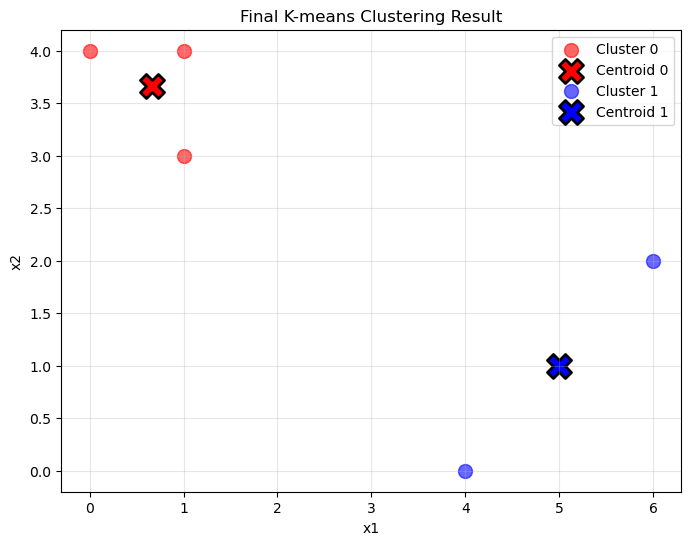

In [5]:
# Repeat (c) and (d) until convergence
max_iterations = 100
iteration = 0
converged = False

print("Starting K-means iterations...\n")
print("="*60)

while not converged and iteration < max_iterations:
    iteration += 1
    print(f"\nIteration {iteration}:")
    print("-" * 60)
    
    # Store old labels to check for convergence
    old_labels = cluster_labels.copy()
    
    # Step (c): Compute centroids
    print("\nStep (c): Computing centroids...")
    centroids = {}
    
    for cluster in [0, 1]:
        cluster_indices = np.where(cluster_labels == cluster)[0]
        
        if len(cluster_indices) > 0:  # Check if cluster is not empty
            centroid_x1 = np.mean(x1[cluster_indices])
            centroid_x2 = np.mean(x2[cluster_indices])
            centroids[cluster] = (centroid_x1, centroid_x2)
            print(f"  Cluster {cluster}: Centroid = ({centroid_x1:.2f}, {centroid_x2:.2f})")
    
    # Step (d): Assign observations to nearest centroid
    print("\nStep (d): Assigning observations to nearest centroid...")
    new_cluster_labels = np.zeros(n_observations, dtype=int)
    
    for i in range(n_observations):
        distances = {}
        
        for cluster in [0, 1]:
            if cluster in centroids:
                centroid = centroids[cluster]
                distance = np.sqrt((x1[i] - centroid[0])**2 + (x2[i] - centroid[1])**2)
                distances[cluster] = distance
        
        closest_cluster = min(distances, key=distances.get)
        new_cluster_labels[i] = closest_cluster
    
    cluster_labels = new_cluster_labels
    
    print(f"  New cluster labels: {cluster_labels}")
    
    # Check for convergence
    if np.array_equal(old_labels, cluster_labels):
        converged = True
        print("\n" + "="*60)
        print(f"✓ Converged after {iteration} iterations!")
        print("="*60)
    else:
        print(f"  Labels changed: continuing...")

print("\n" + "="*60)
print("FINAL RESULTS:")
print("="*60)
print(f"\nFinal cluster labels: {cluster_labels}")
print("\nFinal centroids:")
for cluster in [0, 1]:
    if cluster in centroids:
        print(f"  Cluster {cluster}: ({centroids[cluster][0]:.2f}, {centroids[cluster][1]:.2f})")

print("\nFinal cluster assignments:")
for i in range(n_observations):
    print(f"  Observation {i+1}: ({x1[i]}, {x2[i]}) -> Cluster {cluster_labels[i]}")

# Visualize final clustering
plt.figure(figsize=(8, 6))
colors = ['red', 'blue']
for cluster in [0, 1]:
    cluster_points = cluster_labels == cluster
    plt.scatter(x1[cluster_points], x2[cluster_points], 
                c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.6)
    if cluster in centroids:
        plt.scatter(centroids[cluster][0], centroids[cluster][1], 
                    c=colors[cluster], marker='X', s=300, 
                    edgecolors='black', linewidths=2, label=f'Centroid {cluster}')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Final K-means Clustering Result')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


(f) In your plot from (a), color the observations according to the
 cluster labels obtained.

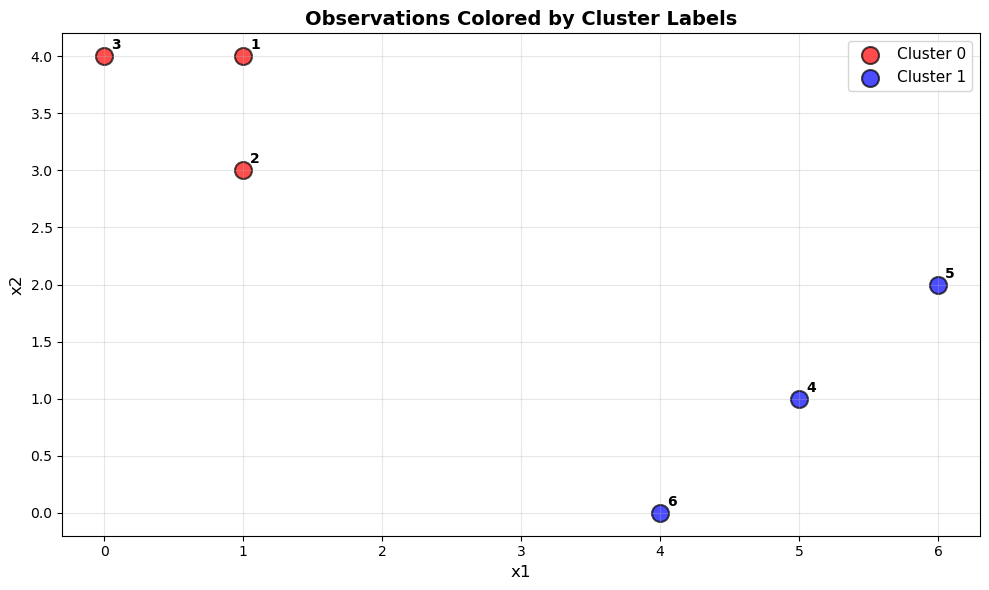

Cluster Assignment Summary:
----------------------------------------
Cluster 0: Observations [np.int64(1), np.int64(2), np.int64(3)]
Cluster 1: Observations [np.int64(4), np.int64(5), np.int64(6)]


In [6]:
# Plot observations colored by their final cluster labels
plt.figure(figsize=(10, 6))

# Define colors for each cluster
colors = ['red', 'blue']
cluster_names = ['Cluster 0', 'Cluster 1']

# Plot each cluster with different colors
for cluster in [0, 1]:
    # Get observations belonging to this cluster
    cluster_mask = cluster_labels == cluster
    
    plt.scatter(x1[cluster_mask], x2[cluster_mask], 
                c=colors[cluster], 
                label=cluster_names[cluster], 
                s=150, 
                alpha=0.7,
                edgecolors='black',
                linewidths=1.5)

# Add labels for each observation
for i in range(n_observations):
    plt.annotate(f'{i+1}', 
                 (x1[i], x2[i]), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=10,
                 fontweight='bold')

plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title('Observations Colored by Cluster Labels', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the cluster assignment summary
print("Cluster Assignment Summary:")
print("-" * 40)
for cluster in [0, 1]:
    cluster_obs = np.where(cluster_labels == cluster)[0] + 1  # +1 for 1-based indexing
    print(f"{cluster_names[cluster]}: Observations {list(cluster_obs)}")
